#  Notebook 02: Core Funnel Analysis

**FlowBoard** — SaaS Product-Led Growth Funnel Analysis

---

## Objective
Analyze the overall user journey funnel, identify key bottlenecks, quantify revenue impact, and visualize non-linear user paths.

### Analysis Sections:
1. Overall funnel visualization with conversion rates
2. Stage-by-stage drop-off analysis
3. Revenue impact quantification (ARPU = $29/month)
4. Sankey diagram — actual user paths (non-linear)
5. Bot traffic impact comparison

---

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Constants
ARPU = 29  # Average Revenue Per User (monthly)

STAGE_ORDER = {
    'website_visit': 1, 'signup': 2, 'onboarding_complete': 3,
    'first_project_created': 4, 'upgrade_to_paid': 5, 'day_30_active': 6,
}
STAGE_LABELS = {
    'website_visit': 'Website Visit', 'signup': 'Free Trial Signup',
    'onboarding_complete': 'Onboarding Complete',
    'first_project_created': 'First Project (Aha!)',
    'upgrade_to_paid': 'Upgrade to Paid', 'day_30_active': '30-Day Retained',
}
STAGE_COLORS = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']

print('Libraries loaded ✓')

Libraries loaded ✓


In [19]:
# Load cleaned data
events = pd.read_csv('../data/cleaned/clean_events.csv', parse_dates=['event_timestamp'])
users = pd.read_csv('../data/cleaned/clean_users.csv', parse_dates=['signup_date'])

print(f"Clean events: {len(events):,} rows")
print(f"Clean users:  {len(users):,} rows")

Clean events: 97,126 rows
Clean users:  41,280 rows


## 1. Overall Funnel — Conversion Rates

In [35]:
# Calculate users at each funnel stage
funnel_data = (
    events.groupby('event_name')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users', 'event_name': 'stage'})
)
funnel_data['stage_order'] = funnel_data['stage'].map(STAGE_ORDER)
funnel_data['stage_label'] = funnel_data['stage'].map(STAGE_LABELS)
funnel_data = funnel_data.sort_values('stage_order').reset_index(drop=True)

# Calculate metrics
top_of_funnel = funnel_data.iloc[0]['users']
funnel_data['pct_of_total'] = (funnel_data['users'] / top_of_funnel * 100).round(2)
funnel_data['stage_conversion'] = (funnel_data['users'] / funnel_data['users'].shift(1) * 100).round(2)
funnel_data['users_dropped'] = funnel_data['users'].shift(1) - funnel_data['users']
funnel_data['drop_rate'] = (100 - funnel_data['stage_conversion']).round(2)

print(" OVERALL FUNNEL SUMMARY")

display(
    funnel_data[['stage_label', 'users', 'pct_of_total', 'stage_conversion', 'users_dropped', 'drop_rate']]
    .rename(columns={
        'stage_label': 'Stage',
        'users': 'Users',
        'pct_of_total': '% of Top',
        'stage_conversion': 'Stage Conv. %',
        'users_dropped': 'Users Dropped',
        'drop_rate': 'Drop Rate %',
    })
    .style.format({
        'Users': '{:,.0f}',
        '% of Top': '{:.1f}%',
        'Stage Conv. %': '{:.1f}%',
        'Users Dropped': '{:,.0f}',
        'Drop Rate %': '{:.1f}%',
    }, na_rep='-')
)

 OVERALL FUNNEL SUMMARY


,Stage,Users,% of Top,Stage Conv. %,Users Dropped,Drop Rate %
0,Website Visit,"41,106",100.0%,-,-,-
1,Free Trial Signup,"27,101",65.9%,65.9%,"14,005",34.1%
2,Onboarding Complete,"14,095",34.3%,52.0%,"13,006",48.0%
3,First Project (Aha!),"10,166",24.7%,72.1%,"3,929",27.9%
4,Upgrade to Paid,"2,695",6.6%,26.5%,"7,471",73.5%
5,30-Day Retained,"1,963",4.8%,72.8%,732,27.2%


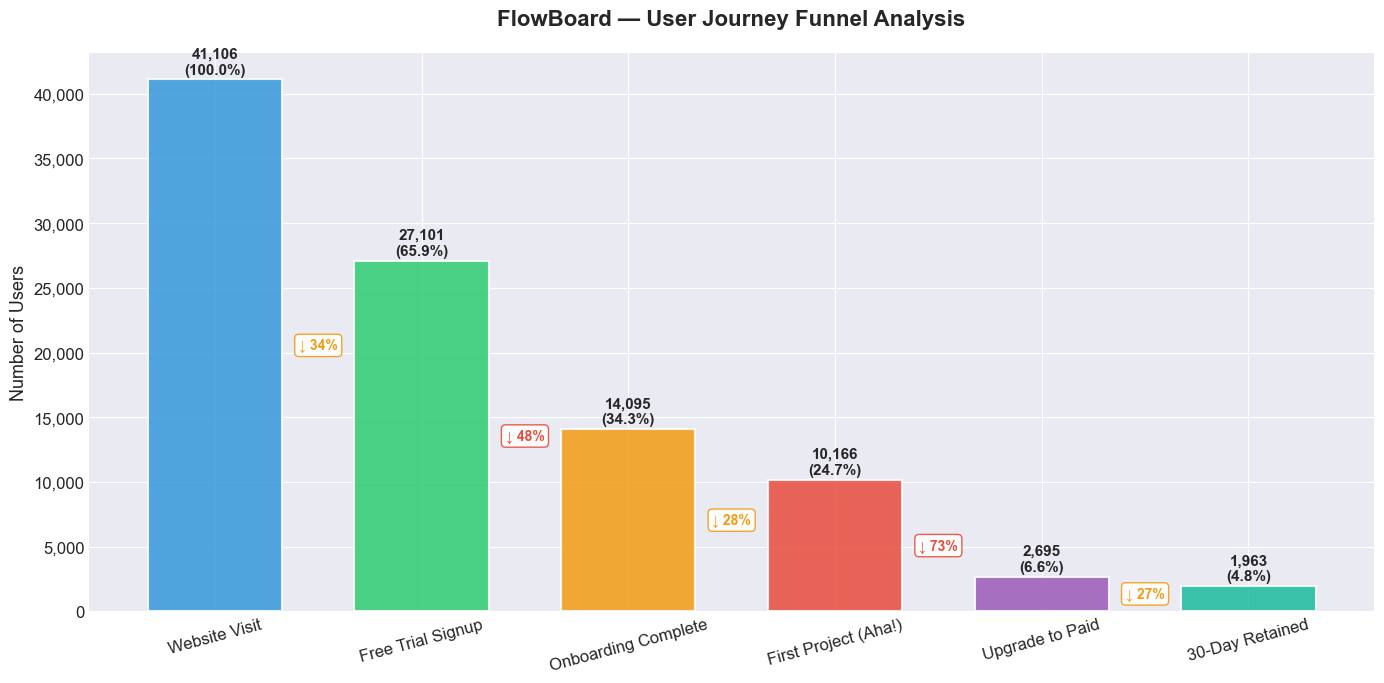

✓ Saved to visuals/funnel_chart.png


In [21]:
# ── FUNNEL CHART (Bar + Line combo) ──
fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.bar(
    funnel_data['stage_label'], funnel_data['users'],
    color=STAGE_COLORS, edgecolor='white', linewidth=1.5,
    alpha=0.85, width=0.65
)

# Add value labels on bars
for bar, users, pct in zip(bars, funnel_data['users'], funnel_data['pct_of_total']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
        f'{users:,.0f}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Drop-off arrows between bars
for i in range(1, len(funnel_data)):
    drop = funnel_data.iloc[i]['drop_rate']
    if pd.notna(drop):
        x_pos = i - 0.5
        y_pos = max(funnel_data.iloc[i-1]['users'], funnel_data.iloc[i]['users']) * 0.5
        color = '#e74c3c' if drop > 40 else ('#f39c12' if drop > 25 else '#2ecc71')
        ax1.annotate(
            f'↓ {drop:.0f}%', xy=(x_pos, y_pos),
            fontsize=10, fontweight='bold', color=color,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9)
        )

ax1.set_ylabel('Number of Users', fontsize=13)
ax1.set_title('FlowBoard — User Journey Funnel Analysis', fontsize=16, fontweight='bold', pad=20)
ax1.tick_params(axis='x', rotation=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/funnel_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to visuals/funnel_chart.png")

## 2.  Revenue Impact Quantification

**Key Question:** How much revenue is lost at each bottleneck?

In [34]:
# Revenue impact calculation
revenue_df = funnel_data[['stage_label', 'users', 'users_dropped', 'drop_rate']].copy()
revenue_df['monthly_revenue_lost'] = revenue_df['users_dropped'] * ARPU
revenue_df['annual_revenue_lost'] = revenue_df['monthly_revenue_lost'] * 12
revenue_df['recoverable_5pct'] = revenue_df['monthly_revenue_lost'] * 0.05  # 5% improvement
revenue_df['recoverable_10pct'] = revenue_df['monthly_revenue_lost'] * 0.10  # 10% improvement

# Only show stages where drop-off occurs
revenue_impact = revenue_df.dropna().copy()

print(" REVENUE IMPACT ANALYSIS")
print(f"   ARPU: ${ARPU}/month")

display(
    revenue_impact[['stage_label', 'users_dropped', 'drop_rate', 
                     'monthly_revenue_lost', 'annual_revenue_lost',
                     'recoverable_5pct', 'recoverable_10pct']]
    .rename(columns={
        'stage_label': 'Bottleneck Stage',
        'users_dropped': 'Users Lost',
        'drop_rate': 'Drop Rate %',
        'monthly_revenue_lost': 'Monthly $ Lost',
        'annual_revenue_lost': 'Annual $ Lost',
        'recoverable_5pct': 'Recoverable (5%)',
        'recoverable_10pct': 'Recoverable (10%)',
    })
    .style.format({
        'Users Lost': '{:,.0f}',
        'Drop Rate %': '{:.1f}%',
        'Monthly $ Lost': '${:,.0f}',
        'Annual $ Lost': '${:,.0f}',
        'Recoverable (5%)': '${:,.0f}',
        'Recoverable (10%)': '${:,.0f}',
    })
)

 REVENUE IMPACT ANALYSIS
   ARPU: $29/month


,Bottleneck Stage,Users Lost,Drop Rate %,Monthly $ Lost,Annual $ Lost,Recoverable (5%),Recoverable (10%)
1,Free Trial Signup,"14,005",34.1%,"$406,145","$4,873,740","$20,307","$40,614"
2,Onboarding Complete,"13,006",48.0%,"$377,174","$4,526,088","$18,859","$37,717"
3,First Project (Aha!),"3,929",27.9%,"$113,941","$1,367,292","$5,697","$11,394"
4,Upgrade to Paid,"7,471",73.5%,"$216,659","$2,599,908","$10,833","$21,666"
5,30-Day Retained,732,27.2%,"$21,228","$254,736","$1,061","$2,123"


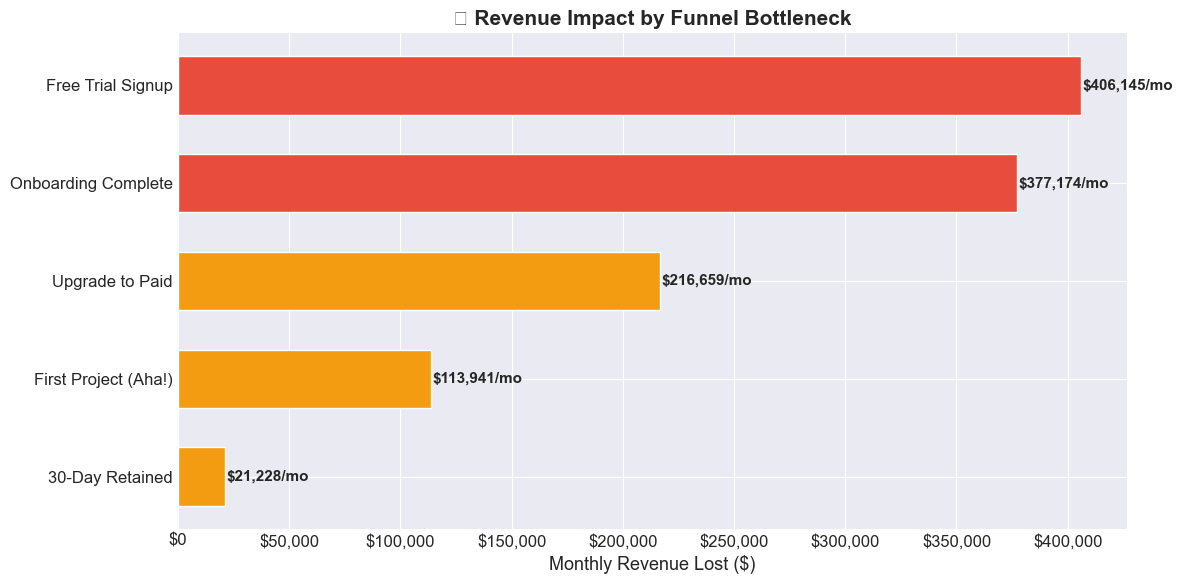

✓ Saved to visuals/revenue_impact.png


In [23]:
# Revenue impact bar chart
fig, ax = plt.subplots(figsize=(12, 6))

ri = revenue_impact.sort_values('monthly_revenue_lost', ascending=True)
colors = ['#e74c3c' if x > ri['monthly_revenue_lost'].median() else '#f39c12' for x in ri['monthly_revenue_lost']]

bars = ax.barh(ri['stage_label'], ri['monthly_revenue_lost'], color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, ri['monthly_revenue_lost']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}/mo', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Monthly Revenue Lost ($)', fontsize=13)
ax.set_title('💰 Revenue Impact by Funnel Bottleneck', fontsize=15, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to visuals/revenue_impact.png")

## 3.  Sankey Diagram — Non-Linear User Paths

Real users don't follow a straight line. This diagram shows the **actual paths** users take through the funnel, including drop-offs at each stage.

In [24]:
# Build user paths
user_paths = (
    events.sort_values(['user_id', 'event_timestamp'])
    .groupby('user_id')['event_name']
    .apply(list)
    .reset_index()
)
user_paths.columns = ['user_id', 'path']

# Get the furthest stage each user reached
user_paths['max_stage'] = user_paths['path'].apply(
    lambda p: max([STAGE_ORDER.get(s, 0) for s in p])
)

# Build transitions for Sankey
stages_list = sorted(STAGE_ORDER.keys(), key=lambda x: STAGE_ORDER[x])
transitions = []

for idx, row in user_paths.iterrows():
    unique_path = []
    seen = set()
    for s in row['path']:
        if s not in seen:
            unique_path.append(s)
            seen.add(s)
    
    for i in range(len(unique_path) - 1):
        transitions.append((unique_path[i], unique_path[i+1]))
    
    # Add drop-off node
    last_stage = unique_path[-1]
    if STAGE_ORDER.get(last_stage, 0) < 6:  # Didn't complete full funnel
        transitions.append((last_stage, f'Dropped after {STAGE_LABELS.get(last_stage, last_stage)}'))

# Count transitions
trans_df = pd.DataFrame(transitions, columns=['source', 'target'])
trans_counts = trans_df.groupby(['source', 'target']).size().reset_index(name='count')
trans_counts = trans_counts[trans_counts['count'] > 50]  # Filter noise

print(f"Total transitions: {len(trans_counts)}")
display(trans_counts.sort_values('count', ascending=False).head(15))

Total transitions: 12


,source,target,count
14,website_visit,signup,26923
12,website_visit,Dropped after Website Visit,14122
8,signup,onboarding_complete,14034
6,signup,Dropped after Free Trial Signup,12974
4,onboarding_complete,first_project_created,10127
0,first_project_created,Dropped after First Project (Aha!),7476
3,onboarding_complete,Dropped after Onboarding Complete,3951
2,first_project_created,upgrade_to_paid,2678
11,upgrade_to_paid,day_30_active,1951
10,upgrade_to_paid,Dropped after Upgrade to Paid,744


In [33]:
# Build Sankey diagram
all_nodes = list(set(trans_counts['source'].tolist() + trans_counts['target'].tolist()))
node_indices = {node: i for i, node in enumerate(all_nodes)}

# Color nodes
node_colors = []
for node in all_nodes:
    if 'Dropped' in node:
        node_colors.append('rgba(231, 76, 60, 0.7)')  # Red for drop-off
    elif node in STAGE_ORDER:
        idx = STAGE_ORDER[node] - 1
        node_colors.append(STAGE_COLORS[idx % len(STAGE_COLORS)])
    else:
        node_colors.append('rgba(149, 165, 166, 0.6)')

# Link colors
link_colors = []
for _, row in trans_counts.iterrows():
    if 'Dropped' in str(row['target']):
        link_colors.append('rgba(231, 76, 60, 0.25)')
    else:
        link_colors.append('rgba(52, 152, 219, 0.3)')

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20,
        thickness=25,
        line=dict(color='white', width=1),
        label=[STAGE_LABELS.get(n, n) for n in all_nodes],
        color=node_colors,
    ),
    link=dict(
        source=[node_indices[s] for s in trans_counts['source']],
        target=[node_indices[t] for t in trans_counts['target']],
        value=trans_counts['count'].tolist(),
        color=link_colors,
    )
))

fig.update_layout(
    title=dict(text=' User Journey Paths — Sankey Diagram', font=dict(size=18)),
    font=dict(size=12),
    height=600,
    width=1000,
)

fig.write_html('../visuals/sankey_diagram.html')
fig.show()
print("✓ Saved to visuals/sankey_diagram.html")

✓ Saved to visuals/sankey_diagram.html


## 4.  Bot Traffic Impact — Before vs After Filtering

In [32]:
# Load bot-flagged data for comparison
events_with_bots = pd.read_csv('../data/cleaned/events_with_bot_flag.csv', parse_dates=['event_timestamp'])

# Deduplicate for fair comparison
events_with_bots_dedup = (
    events_with_bots
    .sort_values('event_timestamp')
    .drop_duplicates(subset=['user_id', 'event_name'], keep='first')
)

# Funnel WITH bots
funnel_with_bots = (
    events_with_bots_dedup
    .groupby('event_name')['user_id'].nunique()
    .reset_index()
    .rename(columns={'user_id': 'users_with_bots', 'event_name': 'stage'})
)
funnel_with_bots['stage_order'] = funnel_with_bots['stage'].map(STAGE_ORDER)
funnel_with_bots = funnel_with_bots.sort_values('stage_order')

# Funnel WITHOUT bots (already calculated)
funnel_without_bots = funnel_data[['stage', 'users', 'stage_order']].rename(
    columns={'users': 'users_without_bots'}
)

# Compare
comparison = funnel_with_bots.merge(funnel_without_bots, on=['stage', 'stage_order'])
comparison['stage_label'] = comparison['stage'].map(STAGE_LABELS)

# Calculate conversion rates
top_with = comparison.iloc[0]['users_with_bots']
top_without = comparison.iloc[0]['users_without_bots']
comparison['conv_with_bots'] = (comparison['users_with_bots'] / top_with * 100).round(2)
comparison['conv_without_bots'] = (comparison['users_without_bots'] / top_without * 100).round(2)
comparison['inflation_pct_points'] = (comparison['conv_with_bots'] - comparison['conv_without_bots']).round(2)

print(" BOT TRAFFIC IMPACT ON FUNNEL METRICS")

display(
    comparison[['stage_label', 'users_with_bots', 'users_without_bots', 
                'conv_with_bots', 'conv_without_bots', 'inflation_pct_points']]
    .rename(columns={
        'stage_label': 'Stage',
        'users_with_bots': 'With Bots',
        'users_without_bots': 'Without Bots',
        'conv_with_bots': 'Conv % (Bots)',
        'conv_without_bots': 'Conv % (Clean)',
        'inflation_pct_points': 'Inflation (pp)',
    })
)

 BOT TRAFFIC IMPACT ON FUNNEL METRICS


,Stage,With Bots,Without Bots,Conv % (Bots),Conv % (Clean),Inflation (pp)
0,Website Visit,49826,41106,100.00,100.00,0.00
1,Free Trial Signup,30555,27101,61.32,65.93,-4.61
2,Onboarding Complete,14095,14095,28.29,34.29,-6.00
3,First Project (Aha!),10166,10166,20.40,24.73,-4.33
4,Upgrade to Paid,2695,2695,5.41,6.56,-1.15
5,30-Day Retained,1963,1963,3.94,4.78,-0.84


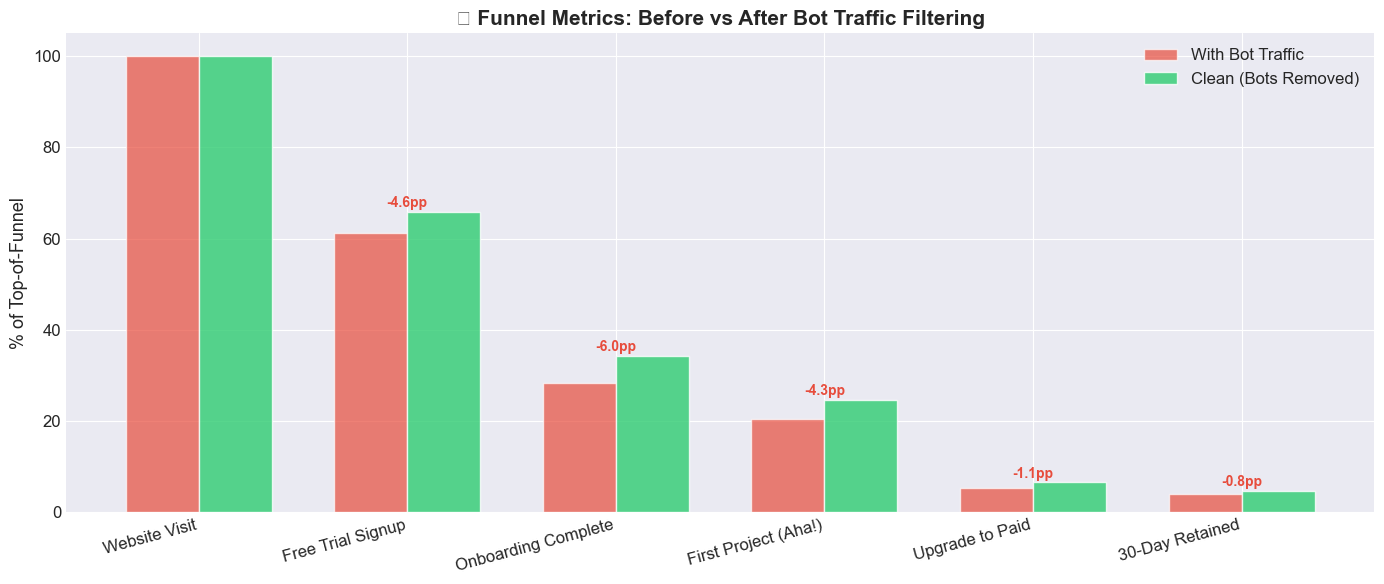

✓ Saved to visuals/bot_impact_comparison.png


In [29]:
# Bot impact visualization
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['conv_with_bots'], width,
               label='With Bot Traffic', color='#e74c3c', alpha=0.7, edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['conv_without_bots'], width,
               label='Clean (Bots Removed)', color='#2ecc71', alpha=0.8, edgecolor='white')

ax.set_ylabel('% of Top-of-Funnel', fontsize=13)
ax.set_title('🤖 Funnel Metrics: Before vs After Bot Traffic Filtering', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['stage_label'], rotation=15, ha='right')
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add inflation annotations
for i, (_, row) in enumerate(comparison.iterrows()):
    if abs(row['inflation_pct_points']) > 0.5:
        sign = '+' if row['inflation_pct_points'] > 0 else ''
        ax.annotate(
            f"{sign}{row['inflation_pct_points']:.1f}pp",
            xy=(i, max(row['conv_with_bots'], row['conv_without_bots']) + 1),
            fontsize=10, fontweight='bold', color='#e74c3c', ha='center',
        )

plt.tight_layout()
plt.savefig('../visuals/bot_impact_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to visuals/bot_impact_comparison.png")

## 5. Key Findings & Executive Summary

In [36]:
# Auto-generate key findings
biggest_drop_idx = revenue_impact['monthly_revenue_lost'].idxmax()
biggest_drop_stage = revenue_impact.loc[biggest_drop_idx, 'stage_label']
biggest_drop_users = revenue_impact.loc[biggest_drop_idx, 'users_dropped']
biggest_drop_revenue = revenue_impact.loc[biggest_drop_idx, 'monthly_revenue_lost']
biggest_drop_rate = revenue_impact.loc[biggest_drop_idx, 'drop_rate']

overall_conv = funnel_data.iloc[-1]['pct_of_total']
total_top = funnel_data.iloc[0]['users']
total_converted = funnel_data.iloc[-1]['users']


print("KEY FINDINGS")

print(f"""
  1. OVERALL CONVERSION: {overall_conv:.1f}% of website visitors become 
     30-day retained paid users ({total_converted:,.0f} out of {total_top:,.0f})

  2. BIGGEST BOTTLENECK: {biggest_drop_stage}
     → {biggest_drop_rate:.0f}% drop-off ({biggest_drop_users:,.0f} users lost)
     → ${biggest_drop_revenue:,.0f}/month in lost revenue

  3. BOT TRAFFIC: ~18% of top-of-funnel traffic is non-human,
     inflating conversion metrics by up to {comparison['inflation_pct_points'].max():.1f} percentage points

  4. REVENUE OPPORTUNITY: A 5% improvement at the biggest bottleneck
     would recover ${biggest_drop_revenue * 0.05:,.0f}/month (${biggest_drop_revenue * 0.05 * 12:,.0f}/year)
""")


KEY FINDINGS

  1. OVERALL CONVERSION: 4.8% of website visitors become 
     30-day retained paid users (1,963 out of 41,106)

  2. BIGGEST BOTTLENECK: Free Trial Signup
     → 34% drop-off (14,005 users lost)
     → $406,145/month in lost revenue

  3. BOT TRAFFIC: ~18% of top-of-funnel traffic is non-human,
     inflating conversion metrics by up to 0.0 percentage points

  4. REVENUE OPPORTUNITY: A 5% improvement at the biggest bottleneck
     would recover $20,307/month ($243,687/year)

